<h1><center>第二章 数据预处理
    <br>Titantic实例分析
    <br>邝神芬 数学与统计学院
</center></h1>

数据挖掘通常包括以下几个阶段：
<br>1.确定问题
<br>2.数据采集
<br>3.数据清洗
<br>4.基础分析
<br>5.算法执行
<br>6.模型评估

Titantic数据是泰坦尼克号上的乘客的信息，2224 名乘客和船员中 891 名的人口学数据和乘客基本信息，这是一个kaggle平台上最经典的数据挖掘入门题目。


In [1]:
#读取训练数据
train = read.csv("/Users/shf/课程资料/dm-titantic/train.csv", na.strings = c("NA",""))

In [2]:
#显示前几行的数据
head(train)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NA,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NA,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,NA,Q


数据集中共有12个字段:
<br>PassengerId：乘客编号
<br>Survived：乘客是否存活
<br>Pclass：乘客所在的船舱等级
<br>Name：乘客姓名
<br>Sex：乘客性别
<br>Age：乘客年龄
<br>SibSp：乘客的兄弟姐妹和配偶数量
<br>Parch：乘客的父母与子女数量
<br>Ticket：票的编号
<br>Fare：票价
<br>Cabin：座位号
<br>Embarked：乘客登船码头


问题提出：预测乘客的生存率，哪些乘客最有可能生存？<br>
Train.csv:包含编号从1-891共891个乘客的12个属性信息，是已知的训练数据集。<br>
Test.csv:包含编号从892-1309共418个乘客的11个属性信息，是测试数据集，其中Survive属性未知，需要通过设计算法对其进行预测。


<center>经验分析：</center>
PassengerId ，乘客的id号，这个我觉得对生存率没影响。<br>
Survived ,生存的标号，上面图的数值1表示这个人很幸运，生存了下来。数值0，则表示遗憾。<br>
Pclass ,船舱等级，就是我们坐船有等级之分，像高铁，飞机都有。这个属性会对生产率有影响。因为一般有钱人，权贵才会住头等舱的。保留。
<br>Name ,名字，这个不影响生存率。我觉得可以不用这列数据。可以忽略
<br>Sex , 性别，这个因为全球都说lady first，女士优先，所有这列保留。
<br>Age , 年龄，因为优先保护老幼，这个保留。
<br>SibSp ,兄弟姐妹，就是有些人和兄弟姐妹一起上船的。这个会有影响，因为有可能因为救他们而导致自己没有上救生船船。保留这列
<br>Parch , 父母和小孩。就是有些人会带着父母小孩上船的。这个也可能因为要救父母小孩耽误上救生船。保留
<br>Ticket , 票的编号。这个没有影响吧。
<br>Fare , 费用。这个和Pclass有相同的道理，有钱人和权贵比较有势力和影响力。这列保留
<br>Cabin ,舱号。住的舱号没有影响。忽略。
<br>Embarked ，上船的地方。这列可能有影响。我认为登陆地点不同，可能显示人的地位之类的不一样。我们先保留这列。
 <br>对数据集初步了解，猜测有以下因素：
<br>Pclass、Sex、Age、SibSp、Parch、Fare、Embarked


 数据预处理，首先观察数据是否存在以下问题
<br>1.缺失
<br>2.冗余
<br>3.噪声
<br>4.合并或添加属性？

In [3]:
#train=as.data.frame(train)

In [4]:
library(Amelia)

Loading required package: Rcpp
## 
## Amelia II: Multiple Imputation
## (Version 1.7.5, built: 2018-05-07)
## Copyright (C) 2005-2018 James Honaker, Gary King and Matthew Blackwell
## Refer to http://gking.harvard.edu/amelia/ for more information
## 


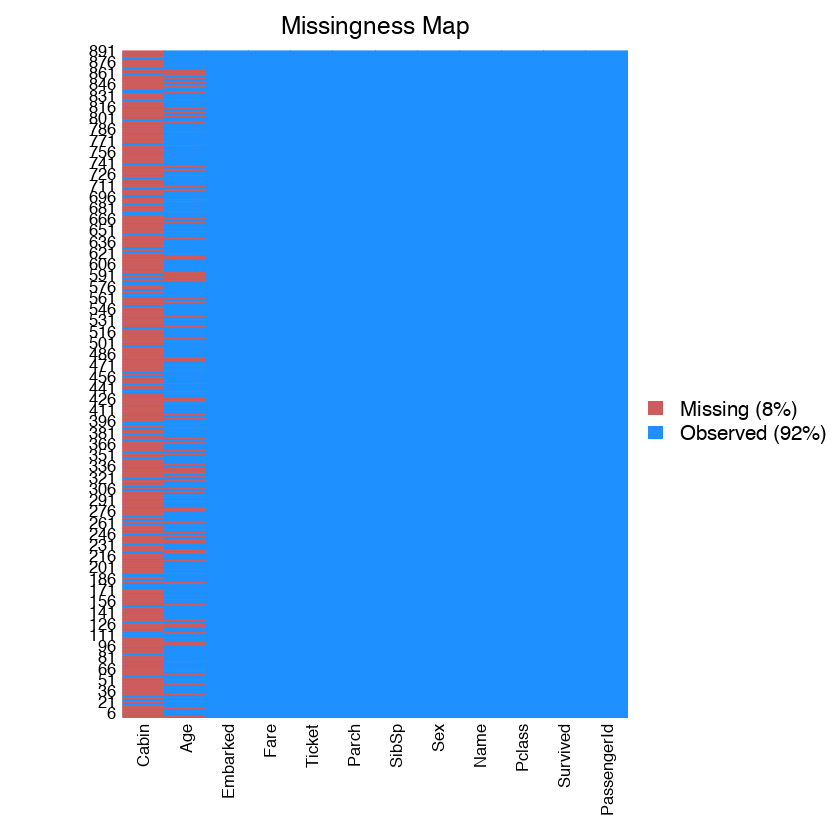

In [5]:
missmap(train)

In [6]:
#去除Cabin这一列
train = train[-11]

In [7]:
head(train)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,Q


In [23]:
#用is.na()判断当成属于值是否包含NA值
 #is.na(train$Age) #或is.na(train[,5])

In [9]:
#is.na()进行了标记，用sum()统计缺失值总数
sum(is.na(train$Age) == TRUE)

[1] 177

In [10]:
#用缺失总数除以非缺失数来计算缺失比例
sum(is.na(train$Age) == TRUE)/length(train$Age)

[1] 0.1986532

In [11]:
#用sapply函数来计算所有属性缺失值的比例：
sapply(train, function(df){
   sum(is.na(df==TRUE))/length(df)})

PassengerId    Survived      Pclass        Name         Sex         Age 
0.000000000 0.000000000 0.000000000 0.000000000 0.000000000 0.198653199 
      SibSp       Parch      Ticket        Fare    Embarked 
0.000000000 0.000000000 0.000000000 0.000000000 0.002244669

In [12]:
#求非缺失值的年龄的平均值
Age = train$Age;
mean(Age,na.rm =TRUE)
#len = sum(!is.na(Age))
#sum(Age,na.rm = TRUE)/len

[1] 29.69912

In [29]:
Age[which(is.na(Age))]=29.699
train$Age <- Age

In [17]:
#创建新变量，用来合并第7和8列
train$relative <- 0
train$relative <- train[,7]+train[,8]
#删除第7和第8列
train <- train[,-c(7,8)]
head(train)

PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,relative
1,0,3,"Braund, Mr. Owen Harris",male,22,A/5 21171,7.2500,S,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,PC 17599,71.2833,C,1
3,1,3,"Heikkinen, Miss. Laina",female,26,STON/O2. 3101282,7.9250,S,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,113803,53.1000,S,1
5,0,3,"Allen, Mr. William Henry",male,35,373450,8.0500,S,0
6,0,3,"Moran, Mr. James",male,NA,330877,8.4583,Q,0


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 177 rows containing non-finite values (stat_bin).”

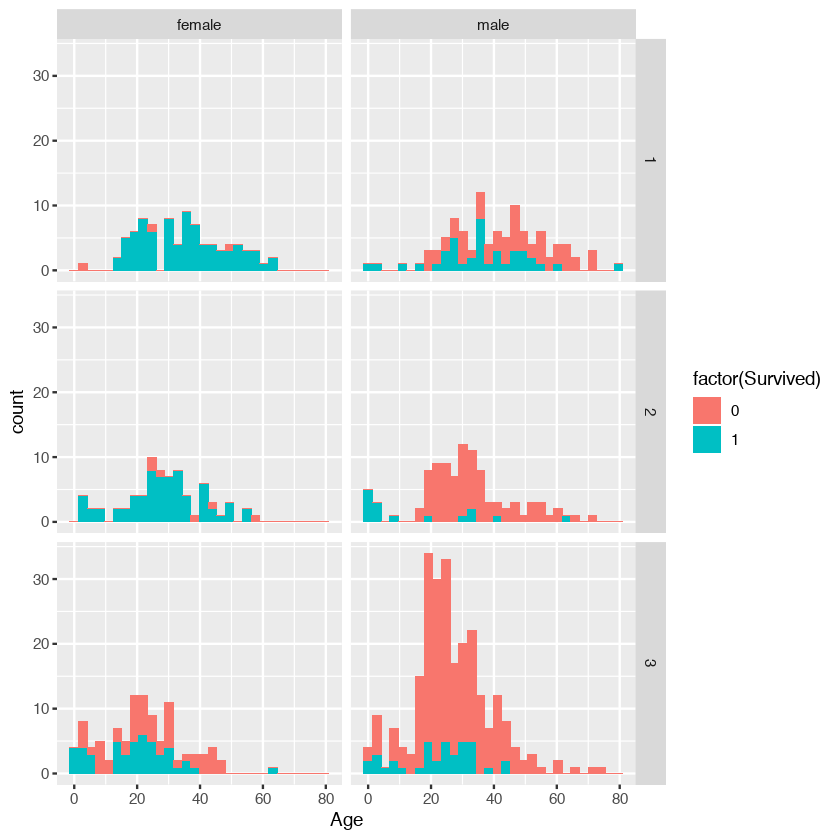

In [16]:
#画图分析男女生存情况
library(ggplot2)
ggplot(train,aes(x=Age,fill=factor(Survived)))+
  geom_histogram()+
  facet_grid(Pclass~Sex)

`geom_smooth()` using method = 'loess' and formula 'y ~ x'
Warning message:
“Removed 177 rows containing non-finite values (stat_smooth).”Warning message:
“Removed 177 rows containing missing values (geom_point).”

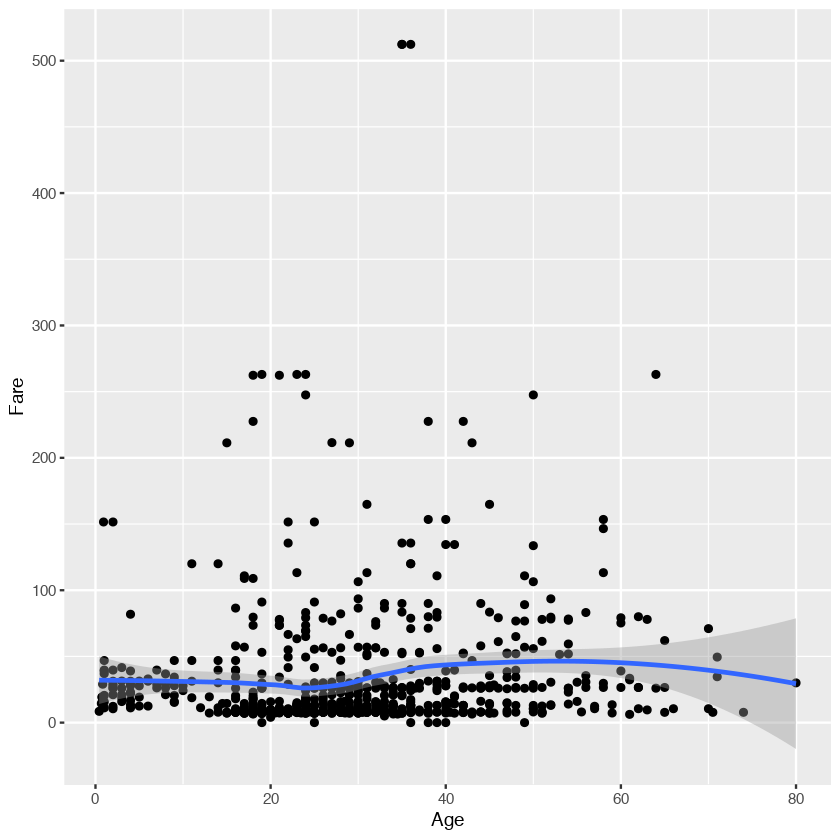

In [22]:
ggplot(train,aes(x=Age,y=Fare))+geom_point()+geom_smooth()

In [32]:
cor(train$Age,train$Survived)
#年龄和是否生存相关性接近0

[1] -0.06980818

In [37]:
cor(as.numeric(train$Sex),train$Survived)
#性别和是否生存相关性为0.5，且负相关，
#通过简单的相关性分析可以发现，性别与年龄相比，性别对能否生存更重要！！

[1] -0.5433514